In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib widget

In [2]:
df = pd.read_csv('../Datasets/scrap price.csv')

In [3]:
df.head()

,ID,symboling,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [4]:
df.columns

Index(['ID', 'symboling', 'name', 'fueltypes', 'aspiration', 'doornumbers',
       'carbody', 'drivewheels', 'enginelocation', 'wheelbase', 'carlength',
       'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber',
       'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price'],
      dtype='object')

In [5]:
# Matriz de características X y vector objetivo y
X = df[["enginesize", "horsepower"]].values
y = df["price"].values.reshape(-1, 1)
y = y[: None]
print(X.shape)
print(y.shape)

(205, 2)
(205, 1)


In [6]:
## Z-score estandarización o normalización
m = np.mean(X)
std = np.std(X)
X = (X - m) / std

In [7]:
# sesgo (bias)
X_b = np.c_[np.ones((len(X), 1)), X]

### Deceso de gradiente clásico

In [8]:
# Inizializar
theta = np.zeros((X_b.shape[1], 1))
lr = 1e-4
# 1e-3 *(1/len(y)) -> para muchos datos
num_iter = 1000
loss = np.zeros([num_iter]) 

In [9]:
for i in range(num_iter):
    h = np.dot(X_b, theta) # Hipotesis
    r = h - y # residuos
    grad = X_b.T@r # gradiente
    theta = theta - lr*grad # actualizacion de theta
    loss[i] = np.mean(r**2) # calculo del error

print(grad.shape)
print("Theta:\n", theta)
# print(loss)


(3, 1)
Theta:
 [[12484.24059894]
 [ 5255.57642953]
 [ 2366.63621379]]


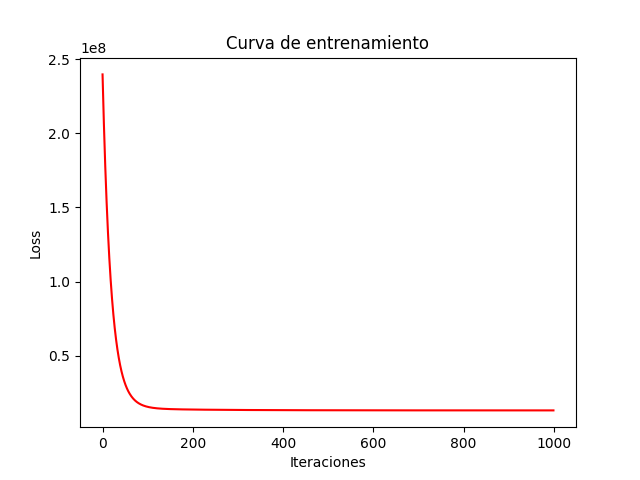

In [10]:
plt.figure()
plt.plot(loss, color="red")
plt.xlabel("Iteraciones")
plt.ylabel("Loss")
plt.title("Curva de entrenamiento")
plt.show()

In [11]:
# Predicciones
y_pred = X_b.dot(theta)

# Calcular función de pérdida (MSE)
mse = np.mean((y - y_pred) ** 2)

print(f"Mean Squared Error: {mse}")
print(f"Predicciones: {y_pred[:5].flatten()}")

Mean Squared Error: 13129098.214487918
Predicciones: [14039.91844009 14039.91844009 19205.9746932  10910.9594616
 15014.25136766]


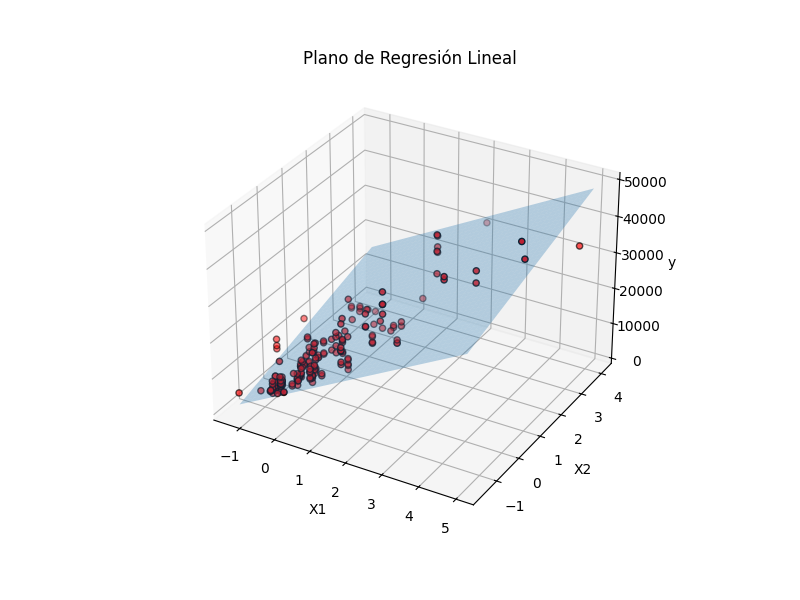

In [12]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_b[:,1], 
           X_b[:,2], 
           y[:,0], 
           color='red', 
           edgecolor='black'
)

# Crear malla
x1_range = np.linspace(X_b[:,1].min(), X_b[:,1].max(), 40)
x2_range = np.linspace(X_b[:,2].min(), X_b[:,2].max(), 40)

x1_surf, x2_surf = np.meshgrid(x1_range, x2_range)

theta_flat = theta.flatten()

# Plano de regresión
y_surf = theta_flat[0] + theta_flat[1]*x1_surf + theta_flat[2]*x2_surf

ax.plot_surface(x1_surf, x2_surf, y_surf, alpha=0.3)

ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("y")
ax.set_title("Plano de Regresión Lineal")

plt.show()

#### Descenso de gradiente estocástico

N: 205
batch_tamaño: 32
num_batches: 6


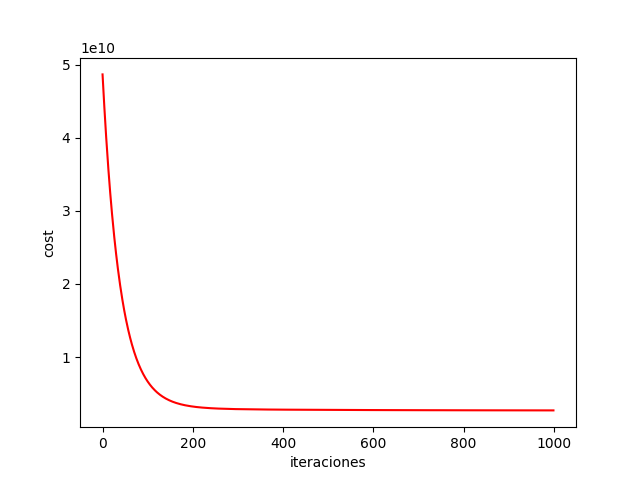

Numero de iteraciones: 999
Theta:
 [[12223.35079615]
 [ 5651.59442681]
 [ 1944.41617054]]


In [13]:
N = len(y)
theta = np.zeros((X_b.shape[1], 1))
lr = 1e-2
num_iter = 1000
j_cost= np.zeros([num_iter])
batch_tamaño = 32
num_batches = int(N / batch_tamaño)
X = X_b
Y = y
Theta_DG=[]

print("N: %d" %N)
print("batch_tamaño: %d" %batch_tamaño)
print("num_batches: %d" % num_batches)

for it in range(num_iter):
    Theta_DG.append(theta)
    cost = 0.0
    indices = np.random.permutation(N)
    X = X[indices,:]
    y = y[indices]
    for i in range(0, N, batch_tamaño):
       X_i = X[i : i + batch_tamaño,:]
       y_i = y[i: i + batch_tamaño] 
       prediction = np.dot(X_i, theta)
       h = prediction - y_i
       si = -(1/N)*lr*( X_i.T.dot(h))
       theta = theta + si
       cost += np.sum(np.square(h))
    j_cost[it] = cost
 
Theta_DG = np.array(Theta_DG).reshape(num_iter, -1) 
prediction = np.dot( X_b,theta)
h=prediction - y
si=-(1/N)*lr*( X_b.T.dot(h))

plt.close('all')
plt.figure()
plt.plot(j_cost[0:it+1], color='r')
plt.xlabel('iteraciones')
plt.ylabel('cost')
plt.show()   

print("Numero de iteraciones: %d" %it)
print("Theta:\n", theta)


[[12403.49773011]
 [ 1289.09401535]
 [-1847.95499478]]


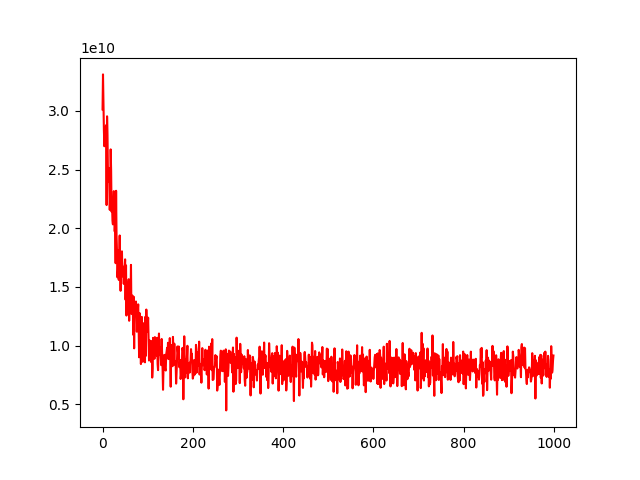

In [14]:
theta=np.zeros((X_b.shape[1],1))
lr=1e-2
num_iter = 1000
j_cost=np.zeros([num_iter])
batch_size = 128

for i in range(num_iter) :
    idx = np.random.choice(len(X_b), batch_size, replace=False)
    X_i = X_b[idx]
    y_i = y[idx]
    h = np.dot(X_i, theta)
    r = h - y_i
    grad = X_i.T @ r / batch_size
    theta = theta - lr * grad
    j_cost[i] = np.sum(np.square(r))

print(theta)
plt.figure()
plt.plot(j_cost, color='red')
plt.show()

### Decenso por gradiente estocástico con momentum

[[12367.09332093]
 [ 1319.3866887 ]
 [-2008.39443568]]


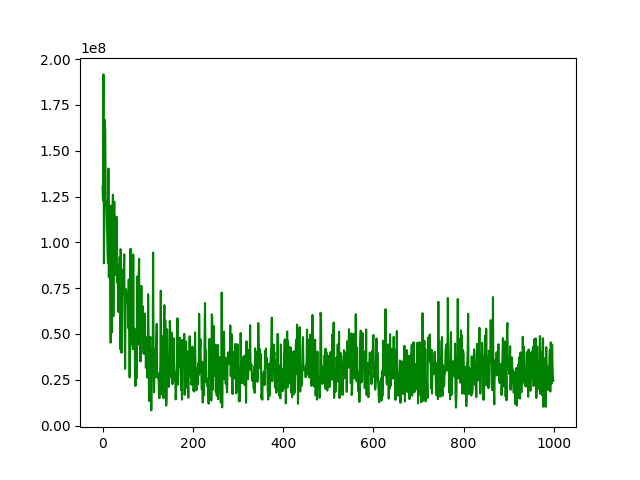

In [15]:
theta = np.zeros((X_b.shape[1], 1))
v = np.zeros_like(theta) #  se Inicializar velocidad en cero
lr = 1e-3
beta = 0.9              
num_iter = 1000
j_cost = np.zeros([num_iter])
batch_size = 32
Theta_SDG=[]

for i in range(num_iter):
    idx = np.random.choice(len(X_b), batch_size, replace=False)
    X_i = X_b[idx]
    y_i = y[idx]
    h = np.dot(X_i, theta)
    r = h - y_i
    grad = X_i.T @ r / batch_size
    v = beta * v + lr * grad
    theta = theta - v
    j_cost[i] = (1 / (2 * batch_size)) * np.sum(np.square(r))
    Theta_SDG.append(theta)

Theta_SDG = np.array(Theta_SDG).reshape(num_iter, -1)

print(theta)
plt.figure()
plt.plot(j_cost, color='green')
plt.show()

In [16]:
print(Theta_SDG.shape)
print(Theta_DG.shape)

(1000, 3)
(1000, 3)


ValueError: input operand has more dimensions than allowed by the axis remapping

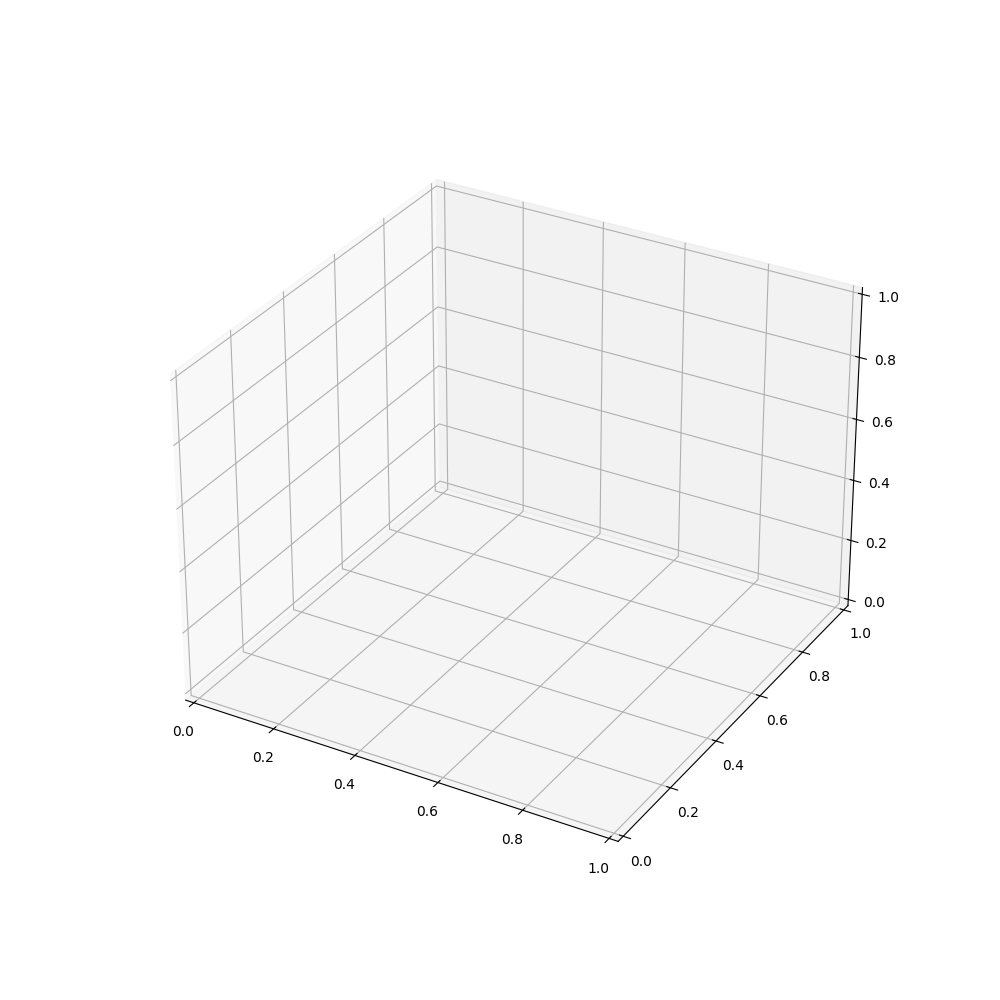

In [17]:
%matplotlib widget
plt.rcParams['legend.fontsize'] = 12
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
nIter=np.expand_dims(np.arange(Theta_DG.shape[0]),1) 
ax.plot(Theta_DG[:,0],  Theta_DG[:,1], nIter[:], label='DG')
ax.plot(Theta_SDG[:,0], Theta_SDG[:,1], nIter[:], label='SGD')
ax.legend()
ax.set_title(r'Trayectorias los parámetros calculados con distintos algoritmos')
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_0$')
ax.set_zlabel('Iteración')